# Demoting the gold-free regime-diagnostic to a heuristic

**A=C identity + signal-redundancy + mispredict audit — zero-API, pure-CPU, `$0.00`.**

This demo notebook reproduces the evaluation `eval.py` that quantitatively **demotes** the
iter-3 *gold-free regime-diagnostic* from a claimed novel contribution to a deployment-time
**heuristic**. It performs **no new measurements** and makes **no LLM calls** — every number
is either an *algebraic identity* or a recomputation over **cached arrays**:

* **Re-DocRED regime-diagnostic** — per-candidate `Z, Zt, W` for 4384 candidates over 152 docs
  (here a curated subset of those confirmatory checkpoints).
* **CLUTRR self-consistency diagonal** — the `primary_disconfirmation_verdict` scalars and the
  multi-hop diagonal rows.

**What it computes (4 metric groups):**
1. **The A≡C identity.** Since `W = sign(Z−Zt)·max(Z,Zt)`, we have `1[W==Z] = 1[Z>Zt]`, hence
   `frac(W==Z | S) = 1 − winrate(S)` **exactly** (up to the measure-zero `Z=Zt=0` edge), in
   *every* candidate set `S`. So signal **C** carries **zero** new information beyond signal **A**.
2. **Signal dependence.** Of the 4 nominal signals, A≡C and B is a refinement of the same axis;
   only D adds a new array → **effective independent axes = 2**.
3. **Regime-map-as-heuristic + mispredict audit** → `independent_and_correct_count = 0`.
4. **Honest figure-ready regime panel** + reframing recommendation.

> The original script reads cached files from sibling experiment directories. This notebook loads
> a curated subset packaged in `mini_demo_data.json` (from GitHub, with a local fallback). The
> A≡C identity holds on *any* subset, so the demo reproduces the central result faithfully; the
> cross-checks against the full cached summary differ slightly because the demo uses fewer docs.


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, install everywhere
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab; install locally to match Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
# --- Imports (copied from the original eval.py, minus the CLI plumbing) ---
import gc
import hashlib
import json
import resource
import sys
from pathlib import Path

import numpy as np
import scipy.stats as st
from loguru import logger

# Logging (as in the original)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
Path("logs").mkdir(exist_ok=True)
logger.add("logs/run.log", rotation="30 MB", level="DEBUG")

# Resource cap. The original also capped virtual memory (RLIMIT_AS) at 12 GB; in a notebook /
# Colab kernel the address-space cap can spuriously trip (many threads reserve virtual arenas),
# and the data here is tiny (a few thousand floats), so we keep only the CPU-time safety net.
try:
    resource.setrlimit(resource.RLIMIT_CPU, (1800, 1800))
except (ValueError, OSError):
    pass

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6db730-decoy-gated-neuro-symbolic-extraction-a/main/round-4/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("top-level keys:", list(data.keys()))
print("n checkpoints packaged:", len(data["redocred_checkpoints"]))
print("cached frac_W_equals_Z (full):", data["exp3_regime_diagnostic"]["signal_C_wz_divergence"]["frac_W_equals_Z"])
print("CLUTRR self-consistency realized_fdr:", data["exp1_primary_disconfirmation_verdict"]["realized_fdr"])

top-level keys: ['_description', 'redocred_checkpoints', 'exp3_regime_diagnostic', 'exp1_primary_disconfirmation_verdict', 'exp1_multi_hop_rows']
n checkpoints packaged: 100
cached frac_W_equals_Z (full): 0.9391
CLUTRR self-consistency realized_fdr: 1.0


## Config

All tunable parameters live here. **Demo defaults are the absolute minimum** that produce
meaningful output. The full original run used **all 152** confirmatory checkpoints and
`BOOT_B = 2000`. Scale `N_CHECKPOINTS` up toward `len(data["redocred_checkpoints"])` (the curated
subset holds 100 of the 152 docs) and `BOOT_B` up toward 2000 for a fuller run.

The A≡C identity is **exact in any subset**, so even the minimum `N_CHECKPOINTS` reproduces the
central result; only the bootstrap CIs and the cross-checks against the full cached summary tighten
as you scale up.

In [5]:
# ---- Tunable parameters ----
# Pure-CPU algebra over a few thousand floats -> the whole eval runs in <1s even at full scale,
# so the demo uses ALL packaged checkpoints. Drop N_CHECKPOINTS to e.g. 3 for an instant smoke test.
N_CHECKPOINTS = 100      # use all 100 packaged docs.  MINIMUM smoke test: 3.  ORIGINAL full run: 152
BOOT_B        = 2000     # doc-block bootstrap iterations for winrate CIs (= ORIGINAL).  MINIMUM: 200
SEED          = 0        # deterministic (original: 0)
RENDER_FIGURE = True     # render the optional regime-panel figure

# Regime thresholds mirrored from the dependency common.py (fixed; not scaled)
REGIME_TAIL_QUANTILES = [0.25, 0.50]
REGIME_EXCH_BAND      = 0.15
REGIME_CALIB_AUC_HI   = 0.65
REGIME_RHO_NULL       = 0.97
REGIME_JACCARD_NULL   = 0.95
KNOCKOFF_ALPHA        = 0.20

## Helper functions (re-implemented exactly from `analyze.py`)

The knockoff+ threshold (Barber–Candès), the document-block bootstrap, and a tie-safe Pearson
correlation between two 0/1 indicator vectors. Copied verbatim from the original so verification is
independent of the prior code path.

In [6]:
def knockoff_plus_threshold(W, alpha):
    """Barber-Candes knockoff+ threshold: smallest |w| cutoff t with (1+#{w<=-t})/max(1,#{w>=t}) <= alpha."""
    if not W:
        return None
    mags = sorted({abs(w) for w in W})
    for t in mags:
        pos = sum(1 for w in W if w >= t)
        neg = sum(1 for w in W if w <= -t)
        fdr_hat = (1 + neg) / max(1, pos)
        if fdr_hat <= alpha:
            return t
    return None


def make_boot_counts(n_docs, B, seed):
    rng = np.random.default_rng(seed)
    return rng.multinomial(n_docs, [1.0 / n_docs] * n_docs, size=B).astype(float)


def ratio_ci(counts, num_vec, den_vec):
    num = counts @ num_vec
    den = counts @ den_vec
    with np.errstate(divide="ignore", invalid="ignore"):
        vals = np.where(den > 0, num / den, np.nan)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return (float("nan"), float("nan"))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


def winrate_doc_ci(rows, doc_list, B, seed):
    """Document-block bootstrap CI for winrate = mean(Zt>=Z) over a subset (resampling docs)."""
    if not rows:
        return (None, None)
    num, den = {}, {}
    for r in rows:
        den[r["doc"]] = den.get(r["doc"], 0.0) + 1.0
        if r["Zt"] >= r["Z"]:
            num[r["doc"]] = num.get(r["doc"], 0.0) + 1.0
    counts = make_boot_counts(len(doc_list), B, seed)
    num_vec = np.array([num.get(d, 0.0) for d in doc_list], float)
    den_vec = np.array([den.get(d, 0.0) for d in doc_list], float)
    lo, hi = ratio_ci(counts, num_vec, den_vec)
    return (round(lo, 6), round(hi, 6))


def pearson_indicator(c_vec, a_vec):
    """Pearson corr between two 0/1 vectors; handle zero-variance gracefully."""
    if len(c_vec) < 2:
        return None
    if c_vec.std() == 0.0 or a_vec.std() == 0.0:
        # constant vector: correlation undefined; report 1.0 iff identical, else 0.0
        return 1.0 if np.array_equal(c_vec, a_vec) else 0.0
    return float(np.corrcoef(c_vec, a_vec)[0, 1])

## Load canonical per-candidate rows + cached summary scalars

The original globs `checkpoints/confirmatory/redocred_*.json`; here we iterate the curated list
packaged in `mini_demo_data.json` (the only change). Each row is `{doc, Z, Zt, W, max(Z,Zt),
contaminated}`. We also pull the small cached **summary scalars** used for cross-checks (Re-DocRED
`regime_diagnostic`) and the regime panel (CLUTRR `primary_disconfirmation_verdict` + multi-hop
diagonal).

In [7]:
def load_rows(checkpoints, limit=None):
    """Build canonical per-candidate rows from the packaged Re-DocRED confirmatory checkpoints
    (adapted from the original file-glob loader: reads the in-memory list instead of disk)."""
    if limit is not None:
        checkpoints = checkpoints[:limit]
    rows = []
    for rec in checkpoints:
        doc = rec.get("title", rec.get("stem"))
        for c in rec.get("candidates", []):
            z, zt, w = c.get("Z"), c.get("Zt"), c.get("W")
            if z is None or zt is None or w is None:
                continue
            rows.append({
                "doc": doc,
                "Z": float(z),
                "Zt": float(zt),
                "W": float(w),
                "max_zzt": max(float(z), float(zt)),
                "contaminated": bool(c.get("decoy_contaminated", False)),
            })
    logger.info(f"Loaded {len(rows)} candidate rows from {len(checkpoints)} confirmatory checkpoints")
    return rows


# cached summary scalars we cross-check against (read from the loaded data, not external files)
rd       = data["exp3_regime_diagnostic"]
pdv      = data["exp1_primary_disconfirmation_verdict"]
mh_rows  = data["exp1_multi_hop_rows"]
mh_05    = next(r for r in mh_rows if abs(r["target_alpha"] - 0.5) < 1e-9)

rep_frac_w_eq_z  = rd["signal_C_wz_divergence"]["frac_W_equals_Z"]
rep_rho_adm      = rd["signal_C_wz_divergence"]["spearman_admission"]
rep_jac          = rd["signal_C_wz_divergence"]["admitted_set_jaccard"]
rep_winrate_tail = rd["winrate_tail_headline"]
rep_calib_auc    = rd["signal_D_calibration"]["calibration_auc"]
clutrr_sc_winrate = 0.482  # reconciliation_narrative: cf tail win-rate ~0.48 under self-consistency

llm_cost = 0.0  # ZERO-API invariant: spend is exactly $0.00
assert 0.0 == 0.0, "zero-API: cost must be exactly 0"

rows = load_rows(data["redocred_checkpoints"], limit=N_CHECKPOINTS)
doc_list = sorted({r["doc"] for r in rows})
n_docs = len(doc_list)
logger.info(f"n_docs={n_docs}  n_candidates={len(rows)}")

14:33:09|INFO   |Loaded 2891 candidate rows from 100 confirmatory checkpoints


14:33:09|INFO   |n_docs=100  n_candidates=2891


## Metric Group 1 — the A≡C identity

`W = sign(Z−Zt)·max(Z,Zt)`. Case (a) `Z>Zt ⇒ W=Z`; (b) `Z<Zt ⇒ W=−Zt≠Z`; (c) `Z==Zt ⇒ W=0`
(`=Z` only if `Z=0`). So `1[W==Z] = 1[Z>Zt]` up to the measure-zero `Z=Zt=0` edge, and since the
signal-A win indicator is `1[Zt>=Z] = 1 − 1[Z>Zt]`, we get **`frac(W==Z | S) = 1 − winrate(S)`
exactly** in any set `S`. The functions below compute this per candidate-set, recompute the
admitted-set Spearman / Jaccard, and audit contamination — all copied verbatim from the original.

In [8]:
def per_set_identity(rows, doc_list):
    Z = np.array([r["Z"] for r in rows])
    Zt = np.array([r["Zt"] for r in rows])
    W = np.array([r["W"] for r in rows])
    maxv = np.array([r["max_zzt"] for r in rows])

    # Define the candidate sets S (gold-free) exactly as regime.signal_A does.
    sets = []
    sets.append(("all", np.ones(len(rows), dtype=bool), "all candidates"))
    for q in REGIME_TAIL_QUANTILES:
        cut = float(np.quantile(maxv, 1.0 - q))
        sets.append((f"top_{int(q * 100)}pct", maxv >= cut, f"max(Z,Zt)>={cut:.3f}"))
    Tk = knockoff_plus_threshold(W.tolist(), KNOCKOFF_ALPHA)
    if Tk is not None:
        sets.append(("knockoff_alpha0.2_admitted", W >= Tk, f"W>={Tk:.3f} (knockoff+ alpha={KNOCKOFF_ALPHA})"))

    out = []
    for name, mask, cutoff in sets:
        zi, zti, wi = Z[mask], Zt[mask], W[mask]
        n = int(mask.sum())
        if n == 0:
            continue
        # EXACT operators: W=sign(Z-Zt)*max(Z,Zt) is bit-identical to Z when Z>Zt and exactly 0 on
        # ties, so the indicators are exact. (np.isclose's default rtol=1e-5 would wrongly merge
        # near-ties into the tie set; we avoid it deliberately.)
        win = (zti >= zi)                                   # signal-A win indicator a_i = 1[Zt>=Z]
        eq = (wi == zi)                                     # signal-C equality indicator c_i = 1[W==Z]
        gt = (zi > zti)                                     # 1[Z>Zt] = 1[Zt<Z]
        tie = (zi == zti)                                   # Z==Zt (exact; sign(Z-Zt)=0 => W=0)
        tie00 = tie & (zi == 0.0)                           # the Z==Zt==0 edge (== residual)
        winrate = float(win.mean())
        frac_eq = float(eq.mean())
        tie_frac = float(tie.mean())
        tie00_frac = float(tie00.mean())
        residual = abs(frac_eq - (1.0 - winrate))
        # EXACT theorem: residual == fraction of Z=Zt=0 rows. Check on UNROUNDED floats.
        resid_eq_tie00 = bool(abs(residual - float(tie00.mean())) <= 1e-12)
        icorr = pearson_indicator(eq.astype(float), gt.astype(float))
        sub_rows = [r for r, m in zip(rows, mask) if m]
        ci = winrate_doc_ci(sub_rows, doc_list, BOOT_B, SEED)
        out.append({
            "set": name,
            "cutoff": cutoff,
            "n": n,
            "winrate": round(winrate, 6),
            "frac_eq": round(frac_eq, 6),
            "one_minus_winrate": round(1.0 - winrate, 6),
            "tie_frac": round(tie_frac, 6),
            "tie00_frac": round(tie00_frac, 6),
            "identity_residual": round(residual, 9),
            "residual_le_tie_frac": bool(residual <= tie_frac + 1e-9),
            "residual_equals_tie00": resid_eq_tie00,
            "indicator_corr_eq_vs_gt": None if icorr is None else round(icorr, 6),
            "winrate_ci": list(ci),
        })
        logger.info(f"  set={name:<26} n={n:<5} winrate={winrate:.5f} frac_eq={frac_eq:.5f} "
                    f"resid={residual:.2e}<=tie={tie_frac:.2e} icorr={icorr}")
    return out


def admitted_set_analysis(rows):
    """Recompute the admitted-set ({W>=0}) Spearman and Jaccard; explain rho=0.99096<1 as forced by W==0 ties."""
    Z = np.array([r["Z"] for r in rows])
    W = np.array([r["W"] for r in rows])
    n = len(rows)
    adm = np.where(W >= 0)[0]
    K = len(adm)
    Wa, Za = W[adm], Z[adm]
    # WITH ties (the reported quantity)
    rho_with = float(st.spearmanr(Wa, Za).statistic) if K > 2 and len(set(Za.tolist())) > 1 else 1.0
    # WITHOUT the W==0 tie rows -> the remaining admitted rows all have W==Z>0 => rho == 1 exactly
    keep = (Wa != 0.0)
    Wk, Zk = Wa[keep], Za[keep]
    rho_without = float(st.spearmanr(Wk, Zk).statistic) if len(Wk) > 2 and len(set(Zk.tolist())) > 1 else 1.0
    n_w0 = int((~keep).sum())
    n_w_eq_z = int((W == Z).sum())
    n_ties = int((Z == np.array([r["Zt"] for r in rows])).sum())
    # Jaccard between admitted set {W>=0} and the equal-size top-Z set
    topZ = set(np.argsort(-Z)[:K].tolist()) if K > 0 else set()
    admset = set(adm.tolist())
    jac = len(topZ & admset) / max(1, len(topZ | admset))
    # full-set Spearman cross-check
    rho_full = float(st.spearmanr(W, Z).statistic) if n > 2 else 1.0
    return {
        "n_candidates": n,
        "n_admitted_W_ge_0": K,
        "n_W_equals_Z_admitted_nonzero": int(len(Wk)),
        "n_W_equals_zero_in_admitted": n_w0,
        "n_W_equals_Z_overall": n_w_eq_z,
        "n_exact_ties_Z_eq_Zt": n_ties,
        "spearman_full": round(rho_full, 6),
        "admitted_spearman_with_ties": round(rho_with, 6),
        "admitted_spearman_without_w0_ties": round(rho_without, 6),
        "admitted_set_jaccard": round(float(jac), 6),
        "explanation": (
            "On the gate-admitted set {W>=0}, every member with Z>Zt has W=Z exactly and every "
            "Z==Zt tie has W=0. Spearman(W,Z)|admitted = 0.99096 < 1 is caused ONLY by the handful "
            "of W==0 tie rows (contaminated-decoy ties); dropping them gives rho = 1.0 exactly. "
            "Hence admitted-set rho->1 and Jaccard->1 are MECHANICALLY FORCED, not evidence of an "
            "independent predictive signal."),
    }


def contamination_audit(rows):
    """Win-rate / frac_eq WITH vs WITHOUT contaminated decoys (decoy_contaminated=True)."""
    def stats(rs):
        if not rs:
            return {"n": 0, "winrate": None, "frac_eq": None}
        Z = np.array([r["Z"] for r in rs]); Zt = np.array([r["Zt"] for r in rs]); W = np.array([r["W"] for r in rs])
        return {"n": len(rs),
                "winrate": round(float((Zt >= Z).mean()), 6),
                "frac_eq": round(float((W == Z).mean()), 6)}
    contam = [r for r in rows if r["contaminated"]]
    clean = [r for r in rows if not r["contaminated"]]
    return {
        "n_contaminated": len(contam),
        "n_clean": len(clean),
        "with_contaminated": stats(rows),
        "contaminated_only": stats(contam),
        "without_contaminated": stats(clean),
        "note": (
            "Contaminated decoys (decoy_contaminated=True, i.e. the decoy triple is itself "
            "accidentally entailed so Zt~Z) INFLATE the apparent decoy win-rate. Excluding them "
            "the marginal exchangeability is even LOWER, which STRENGTHENS the demotion (decoys are "
            "even more clearly too-easy). The A=C identity holds in every slice."),
    }


def _verify_cases(rows):
    """Machine-check each algebraic case on the canonical checkpoint data."""
    Z = np.array([r["Z"] for r in rows]); Zt = np.array([r["Zt"] for r in rows]); W = np.array([r["W"] for r in rows])
    out = []
    # case a: Z>Zt => W==Z (exact)
    m = Z > Zt
    out.append({"case": "a", "condition": "Z>Zt", "n": int(m.sum()),
                "all_hold": bool(np.all(W[m] == Z[m])) if m.any() else True,
                "check": "W==Z"})
    # case b: Z<Zt => W==-Zt (tight atol; negation/max are exact in float)
    m = Z < Zt
    out.append({"case": "b", "condition": "Z<Zt", "n": int(m.sum()),
                "all_hold": bool(np.all(np.abs(W[m] - (-Zt[m])) <= 1e-12)) if m.any() else True,
                "check": "W==-Zt"})
    # case c: Z==Zt => W==0 (exact equality; sign(0)=0)
    m = Z == Zt
    out.append({"case": "c", "condition": "Z==Zt", "n": int(m.sum()),
                "all_hold": bool(np.all(W[m] == 0.0)) if m.any() else True,
                "check": "W==0"})
    return out


# ----- run GROUP 1 -----
per_set = per_set_identity(rows, doc_list)
adm = admitted_set_analysis(rows)
contam = contamination_audit(rows)

14:33:09|INFO   |  set=all                        n=2891  winrate=0.05880 frac_eq=0.94293 resid=1.73e-03<=tie=5.88e-03 icorr=0.9842804441568241


14:33:09|INFO   |  set=top_25pct                  n=723   winrate=0.04979 frac_eq=0.95021 resid=0.00e+00<=tie=5.53e-03 icorr=0.9999999999999999


14:33:09|INFO   |  set=top_50pct                  n=1446  winrate=0.03873 frac_eq=0.96127 resid=0.00e+00<=tie=4.84e-03 icorr=1.0


14:33:09|INFO   |  set=knockoff_alpha0.2_admitted n=2738  winrate=0.00621 frac_eq=0.99562 resid=1.83e-03<=tie=6.21e-03 icorr=0.8393971831562097


### Assemble the A≡C identity verdict

Compute `corr(a,c)` over the full set (`a=1[Zt>=Z]`, `c=1[W==Z]`, expected `≈ −1`), check that the
per-set residual equals the `Z=Zt=0` tie fraction in every set, and emit the `CONFIRMED`/`WEAK`
verdict + the full identity block (verbatim from the original `main()`).

In [9]:
by_set = {d["set"]: d for d in per_set}
full = by_set["all"]
top50 = by_set.get("top_50pct")
max_resid = max(d["identity_residual"] for d in per_set)
max_tie = max(d["tie_frac"] for d in per_set)
icorrs = [d["indicator_corr_eq_vs_gt"] for d in per_set if d["indicator_corr_eq_vs_gt"] is not None]
min_icorr = min(icorrs) if icorrs else None
# corr(a,c): a=1[Zt>=Z], c=1[W==Z] over the FULL set -> expect ~ -1
Zall = np.array([r["Z"] for r in rows]); Ztall = np.array([r["Zt"] for r in rows]); Wall = np.array([r["W"] for r in rows])
a_vec = (Ztall >= Zall).astype(float)
c_vec = (Wall == Zall).astype(float)
corr_a_c = pearson_indicator(a_vec, c_vec)

# The EXACT theorem is: residual(S) == tie00_frac(S) (the Z=Zt=0 edge) in EVERY set, hence
# residual(S) <= tie_frac(S). The verdict is gated on that exact condition plus |corr(a,c)| ~ 1.
all_residual_ok = all(d["residual_le_tie_frac"] for d in per_set)
residual_equals_tie00 = all(d["residual_equals_tie00"] for d in per_set)
identity_verdict = ("CONFIRMED" if (all_residual_ok and residual_equals_tie00
                                    and corr_a_c is not None and abs(corr_a_c) >= 0.95) else "WEAK")
verdict_basis = (
    f"residual==tie00_frac exactly in all {len(per_set)} sets (max_residual={max_resid:.3e} == "
    f"Z=Zt=0 fraction); residual<=tie_frac everywhere; corr(a,c)={None if corr_a_c is None else round(corr_a_c,6)} "
    f"~ -1; admitted Spearman without W=0 ties = {adm['admitted_spearman_without_w0_ties']} (==1.0, "
    "mechanically forced). The per-set indicator_corr dips below 0.999 ONLY on the full/admitted "
    "sets because of the Z=Zt=0 edge the theorem excludes; clean top tails give exactly 1.0.")

a_equals_c_identity = {
    "formal_statement": (
        "W_i = sign(Z_i - Zt_i) * max(Z_i, Zt_i). Case (a) Z_i>Zt_i => W_i=Z_i; (b) Z_i<Zt_i => "
        "W_i=-Zt_i != Z_i (scores>=0); (c) Z_i=Zt_i => W_i=0 (=Z_i only if Z_i=0). Therefore "
        "1[W_i=Z_i] = 1[Z_i>Zt_i] modulo the measure-zero Z=Zt=0 edge. The signal-A win indicator "
        "is 1[Zt_i>=Z_i] = 1 - 1[Z_i>Zt_i]. Hence for ANY candidate set S: "
        "frac(W==Z | S) = 1 - winrate(S) EXACTLY, up to the Z=Zt=0 tie fraction. Signal C is an "
        "algebraic restatement of signal A and carries ZERO new information."),
    "case_table": [
        {"case": "a", "condition": "Z>Zt", "predicted_W": "Z", "W_equals_Z": True},
        {"case": "b", "condition": "Z<Zt", "predicted_W": "-Zt", "W_equals_Z": False},
        {"case": "c", "condition": "Z==Zt", "predicted_W": "0", "W_equals_Z": "only if Z==0"},
    ],
    "case_table_empirical": _verify_cases(rows),
    "per_set_table": per_set,
    "admitted_set": adm,
    "contamination_audit": contam,
    "max_residual": round(max_resid, 9),
    "max_tie_frac": round(max_tie, 6),
    "residual_equals_tie00_all_sets": bool(residual_equals_tie00),
    "indicator_corr_headline_top50pct": (by_set["top_50pct"]["indicator_corr_eq_vs_gt"] if top50 else None),
    "indicator_corr_min": None if min_icorr is None else round(min_icorr, 6),
    "corr_a_c_full": None if corr_a_c is None else round(corr_a_c, 6),
    "admitted_spearman_with_ties": adm["admitted_spearman_with_ties"],
    "admitted_spearman_without_ties": adm["admitted_spearman_without_w0_ties"],
    "headline_cross_checks": {
        "full_winrate_recomputed": full["winrate"],
        "one_minus_frac_W_equals_Z_reported": round(1.0 - rep_frac_w_eq_z, 6),
        "full_winrate_vs_1mfracWZ_residual": round(abs(full["winrate"] - (1.0 - rep_frac_w_eq_z)), 6),
        "top50_frac_eq_recomputed": (top50["frac_eq"] if top50 else None),
        "one_minus_winrate_tail_headline": round(1.0 - rep_winrate_tail, 6),
        "reported_frac_W_equals_Z": rep_frac_w_eq_z,
        "reported_admitted_spearman": rep_rho_adm,
        "recomputed_admitted_spearman_with_ties": adm["admitted_spearman_with_ties"],
        "reported_admitted_jaccard": rep_jac,
        "recomputed_admitted_jaccard": adm["admitted_set_jaccard"],
    },
    "verdict": identity_verdict,
    "verdict_basis": verdict_basis,
}
logger.info(f"A=C identity verdict: {identity_verdict}  max_residual={max_resid:.3e} "
            f"max_tie_frac={max_tie:.3e} corr(a,c)={corr_a_c}")

14:33:09|INFO   |A=C identity verdict: CONFIRMED  max_residual=1.826e-03 max_tie_frac=6.209e-03 corr(a,c)=-0.9842804441568241


## Metric Group 2 — signal dependence

The diagnostic nominally advertises **4 signals**, but the decoy-exchangeability axis is
**double-counted**: A≡C (proved above) and B is a distributional refinement of the *same* axis.
Only D introduces a genuinely new array (the self-consistency frequency `f`). → **effective
independent axes = 2**.

In [10]:
signal_dependence = {
    "corr_a_c": None if corr_a_c is None else round(corr_a_c, 6),
    "raw_array_overlap_table": [
        {"signal": "A (tail decoy win-rate)", "reads": ["Z", "Zt"], "new_array_vs_A": "-"},
        {"signal": "B (spontaneous-error CDF match)", "reads": ["Z", "Zt", "f"],
         "new_array_vs_A": "f used only to SELECT the low-f real subset; same (Z,Zt) exchangeability axis"},
        {"signal": "C (W-vs-Z divergence)", "reads": ["W=f(Z,Zt)"],
         "new_array_vs_A": "NONE (W is a deterministic function of Z,Zt)"},
        {"signal": "D (base-scorer calibration)", "reads": ["Z", "f"],
         "new_array_vs_A": "f (self-consistency) — the only genuinely new array"},
    ],
    "nominal_signal_count": 4,
    "axes_after_collapse": 2,
    "macro_axes": ["decoy-exchangeability {A == C, B a distributional refinement}",
                   "base-scorer-calibration {D, via f}"],
    "c_redundant_with_a": True,
    "b_same_axis_as_a": True,
    "note": (
        "The diagnostic NOMINALLY advertises 4 signals, but the decoy-exchangeability axis is "
        "DOUBLE-COUNTED: A and C are algebraically identical (corr(a,c)~-1, frac(W==Z)=1-winrate) "
        "and B is a distributional refinement of the SAME axis. Only D introduces a genuinely new "
        "array (the self-consistency frequency f). Effective independent axes = 2 "
        "(decoy-exchangeability x base-scorer-calibration)."),
}
logger.info(f"effective_independent_axes=2  corr(a,c)={signal_dependence['corr_a_c']}")

14:33:09|INFO   |effective_independent_axes=2  corr(a,c)=-0.98428


## Metric Groups 3 & 4 — regime panel + mispredict audit

A 4-point / 2-anchor honest panel. The map's one validated anchor (Re-DocRED null) is
**near-mechanical** (triggered by `frac(W==Z)=0.94` = signal C, which restates the realized null);
it **mispredicts** CLUTRR self-consistency (marginal win-rate `0.482` ⇒ predicted "gate adds value",
yet the powered paired diagonal is **DISCONFIRMED**, realized FDR `1.0`). →
`independent_and_correct_count = 0`. Includes the demotion verdict, the figure-panel arrays + caption,
and the reframing recommendation.

In [11]:
points = [
    {
        "label": "Re-DocRED (logprob)",
        "winrate_tail": rep_winrate_tail,
        "calibration_auc": rep_calib_auc,
        "predicted_regime": "GATE REDUNDANT",
        "predicted_wedge_sign": "null",
        "realized_outcome": "null (no matched-recall point with delta-CI entirely > 0)",
        "mispredict": False,
        "near_mechanical": True,
        "independent_and_correct": False,
        "source": "realized_this_run",
        "note": ("Prediction is TRIGGERED by rerank_blocked (frac(W==Z)=0.9391 >= 0.90) = SIGNAL C, "
                 "which Group 1 proves equals signal A; 'gate keeps & orders the same facts => null "
                 "wedge' is a near-RESTATEMENT of the realized null. Correct but near-mechanical."),
    },
    {
        "label": "CLUTRR (self-consistency)",
        "winrate_tail": clutrr_sc_winrate,
        "calibration_auc": None,
        "predicted_regime": "GATE ADDS VALUE",
        "predicted_wedge_sign": "positive",
        "realized_outcome": (f"DISCONFIRMED (realized FDR {pdv['realized_fdr']} at alpha*="
                             f"{pdv['alpha_star']}, CI {pdv['ci']}, decoy_fdr_hat={pdv['decoy_fdr_hat']})"),
        "mispredict": True,
        "near_mechanical": False,
        "independent_and_correct": False,
        "source": "realized_experiment_1_paired_diagonal",
        "note": ("MARGINAL win-rate 0.482 ~ 0.5 => heuristic predicts 'gate adds value' (positive); "
                 "the POWERED PAIRED diagonal DISCONFIRMS (realized FDR 1.0, CI [0.66,1.0], "
                 "self-report anti-conservative). The marginal statistic is structurally blind to "
                 "the paired sign-flip failure — this is the headline marginal!=paired lesson "
                 "surfaced as the heuristic's misprediction."),
    },
    {
        "label": "CLUTRR (verbalized)",
        "winrate_tail": 0.103,
        "calibration_auc": None,
        "predicted_regime": "GATE WORSE/anti-conservative",
        "predicted_wedge_sign": "negative",
        "realized_outcome": "anti-conservative (iter-2 reported)",
        "mispredict": False,
        "near_mechanical": False,
        "independent_and_correct": False,
        "source": "hypothesis_reported",
        "note": "Not validated at the powered paired standard; flagged source=hypothesis_reported (iter-2).",
    },
    {
        "label": "CLUTRR (logprob)",
        "winrate_tail": 0.34,
        "calibration_auc": None,
        "predicted_regime": "GATE WORSE/anti-conservative",
        "predicted_wedge_sign": "negative",
        "realized_outcome": "anti-conservative (iter-2 reported)",
        "mispredict": False,
        "near_mechanical": False,
        "independent_and_correct": False,
        "source": "hypothesis_reported",
        "note": "Not validated at the powered paired standard; flagged source=hypothesis_reported (iter-2).",
    },
]
mispredict_count = sum(1 for p in points if p["mispredict"])
near_mechanical_count = sum(1 for p in points if p["near_mechanical"])
independent_and_correct_count = sum(1 for p in points if p["independent_and_correct"])

regime_panel = {
    "points": points,
    "mispredict_count": mispredict_count,
    "near_mechanical_count": near_mechanical_count,
    "independent_and_correct_count": independent_and_correct_count,
    "scorecard_note": (
        "An anchor counts toward independent_and_correct ONLY if its prediction is (a) NON-mechanical "
        "AND (b) correct against a realized PAIRED-standard outcome. Re-DocRED: correct-but-mechanical. "
        "CLUTRR self-consistency: independent-but-WRONG. verbalized/logprob: not validated at the "
        "paired standard. Result = 0."),
}

demotion_verdict = {
    "status": "HEURISTIC (demoted from novel contribution)",
    "reasons": [
        "signal C is algebraically identical to signal A: frac(W==Z)=1-winrate, "
        f"corr(a,c)={signal_dependence['corr_a_c']}, identity_residual<=tie_frac "
        f"(max residual {round(max_resid, 9)} <= max tie_frac {round(max_tie, 6)})",
        "the one validated anchor (Re-DocRED) prediction is near-mechanical: rerank_blocked via "
        "frac(W==Z) restates the realized null",
        "the map MISPREDICTS CLUTRR self-consistency (predicted positive from marginal 0.482; "
        f"realized paired diagonal DISCONFIRMED, realized FDR {pdv['realized_fdr']})",
        "a 4-point 2-anchor illustration, NOT a powered regression; <3 genuinely held-out anchors",
    ],
    "recommend": ("present as a deployment-time heuristic with stated A==C redundancy; do NOT present "
                  "'W==Z so ranking unchanged' as a forecast"),
    "independent_and_correct_count": independent_and_correct_count,
    "effective_independent_axes": 2,
}

figure_panel = {
    "x_winrate_tail": [rep_winrate_tail, clutrr_sc_winrate, 0.103, 0.34],
    "x_label": ("marginal decoy win-rate = 1-frac(W==Z) — a MARGINAL statistic; structurally blind "
                "to the paired sign-flip"),
    "y_calibration_auc": [rep_calib_auc, None, None, None],
    "y_label": "base-scorer calibration AUC(Z, 1[f>=0.5])  (cached; null where not persisted)",
    "y_null_note": ("AUC not cached for the 3 CLUTRR hypothesis-reported points — placed on the "
                    "low-calibration band by base_scorer_calibrated=false; value NOT fabricated."),
    "labels": ["Re-DocRED (logprob)", "CLUTRR (self-consistency)", "CLUTRR (verbalized)", "CLUTRR (logprob)"],
    "predicted_sign": ["null", "positive", "negative", "negative"],
    "realized_outcome": ["null", f"DISCONFIRMED (FDR {pdv['realized_fdr']})",
                         "anti-conservative (iter-2)", "anti-conservative (iter-2)"],
    "flag": ["near_mechanical", "MISPREDICT", "reported", "reported"],
    "exch_band": [0.35, 0.65],
    "calib_hi": REGIME_CALIB_AUC_HI,
    "caption": (
        "Honest gold-free, zero-API regime panel (CPU-only, $0). The x-axis is the MARGINAL decoy "
        "win-rate, which equals 1-frac(W==Z): signals A and C are therefore the SAME axis, not two "
        "independent forecasts. This is a 4-POINT 2-ANCHOR ILLUSTRATION, not a powered regression. "
        "The map MISPREDICTS CLUTRR self-consistency: marginal win-rate 0.482 => predicted 'gate adds "
        "value' (positive), yet the powered paired diagonal DISCONFIRMS (realized FDR 1.0, CI "
        "[0.66,1.0]). Its single 'correct' Re-DocRED prediction is near-mechanical because "
        "rerank_blocked (frac(W==Z)=0.94) merely restates the realized null. Conclusion: the "
        "regime-diagnostic is a deployment-time HEURISTIC, not a validated predictor."),
}

reframing_recommendation = (
    "The paper should LEAD with the marginal-vs-paired conceptual contribution (a marginal "
    "exchangeability statistic such as the decoy win-rate = 1-frac(W==Z) cannot certify the PAIRED "
    "sign-flip property that the FDR gate needs), powered by Artifacts 1-2 (the CLUTRR self-consistency "
    "paired diagonal and Re-DocRED wedge). The gold-free regime-diagnostic should be presented as a "
    "deployment-time HEURISTIC with explicitly stated A==C redundancy (frac(W==Z)=1-winrate, so signal "
    "C adds nothing over signal A), and the artifact must NEVER present 'W==Z so ranking unchanged' as "
    "a forecast — it is an algebraic identity that mechanically restates a null wedge. The heuristic "
    "mispredicts exactly where the marginal/paired distinction bites (CLUTRR self-consistency), which "
    "is itself the strongest illustration of the headline lesson.")

logger.info(f"regime mispredict={mispredict_count} near_mechanical={near_mechanical_count} "
            f"independent_and_correct={independent_and_correct_count}")

14:33:09|INFO   |regime mispredict=1 near_mechanical=1 independent_and_correct=0


## Reproducibility + assemble `eval_out.json`

Compute a deterministic hash over the loaded checkpoint data (the original hashes the two cached
`full_method_out.json` files + 152 checkpoints; here we hash the curated subset), assemble the flat
`metrics_agg`, the schema-conformant `datasets`, and write `eval_out.json`. The `assert llm_cost ==
0.0` enforces the zero-API invariant.

In [12]:
def _reproducibility(data):
    """Deterministic hash over the loaded checkpoint subset (adapted: the original hashes the two
    cached full_method_out.json files + the 152 on-disk confirmatory checkpoints)."""
    roll = hashlib.sha256()
    for rec in data["redocred_checkpoints"]:
        roll.update(rec.get("stem", "").encode())
        roll.update(json.dumps(rec.get("candidates", []), sort_keys=True).encode())
    return {"input_data_combined_sha256": roll.hexdigest(),
            "n_checkpoints_in_demo": len(data["redocred_checkpoints"]),
            "code_entrypoint": "code_demo.ipynb",
            "deterministic": True, "seed": SEED, "bootstrap_B": BOOT_B,
            "note": "All primary numbers are exact; only winrate CIs use the seeded doc-block bootstrap."}

repro = _reproducibility(data)

# ----- metrics_agg (flat numeric only) -----
metrics_agg = {
    "n_candidates_redocred": float(len(rows)),
    "n_docs": float(n_docs),
    "max_identity_residual": round(max_resid, 9),
    "max_tie_frac": round(max_tie, 6),
    "indicator_corr_min": (round(min_icorr, 6) if min_icorr is not None else -999.0),
    "corr_a_c_full": (round(corr_a_c, 6) if corr_a_c is not None else -999.0),
    "full_winrate": full["winrate"],
    "full_frac_W_equals_Z": full["frac_eq"],
    "full_winrate_vs_reported_1mfracWZ_residual": round(abs(full["winrate"] - (1.0 - rep_frac_w_eq_z)), 6),
    "top50_winrate": (top50["winrate"] if top50 else -999.0),
    "top50_frac_eq": (top50["frac_eq"] if top50 else -999.0),
    "admitted_spearman_with_ties": adm["admitted_spearman_with_ties"],
    "admitted_spearman_without_ties": adm["admitted_spearman_without_w0_ties"],
    "admitted_set_jaccard": adm["admitted_set_jaccard"],
    "n_admitted_W_ge_0": float(adm["n_admitted_W_ge_0"]),
    "n_W_equals_Z_overall": float(adm["n_W_equals_Z_overall"]),
    "n_exact_ties_Z_eq_Zt": float(adm["n_exact_ties_Z_eq_Zt"]),
    "n_contaminated": float(contam["n_contaminated"]),
    "winrate_without_contaminated": (contam["without_contaminated"]["winrate"]
                                     if contam["without_contaminated"]["winrate"] is not None else -999.0),
    "nominal_signal_count": 4.0,
    "effective_independent_axes": 2.0,
    "regime_mispredict_count": float(mispredict_count),
    "regime_near_mechanical_count": float(near_mechanical_count),
    "regime_independent_and_correct_count": float(independent_and_correct_count),
    "signal_D_calibration_auc_cached": rep_calib_auc,
    "clutrr_sc_realized_fdr": float(pdv["realized_fdr"]),
    "clutrr_sc_decoy_fdr_hat": float(pdv["decoy_fdr_hat"]),
    "clutrr_sc_alpha_star": float(pdv["alpha_star"]),
    "clutrr_sc_n_admitted": float(mh_05["n_admitted"]),
    "clutrr_sc_n_false_admitted": float(mh_05["n_false_admitted"]),
    "llm_cost_usd": llm_cost,
}

# ----- datasets (schema-conformant: input/output strings + metadata_/eval_ fields) -----
ds_identity_examples = []
for d in per_set:
    ex = {
        "input": f"Re-DocRED candidate set S='{d['set']}' ({d['cutoff']}), n={d['n']}: "
                 f"verify frac(W==Z) == 1 - winrate up to the Z=Zt=0 tie fraction.",
        "output": (f"winrate={d['winrate']}, frac_eq={d['frac_eq']}, 1-winrate={d['one_minus_winrate']}, "
                   f"residual={d['identity_residual']} <= tie_frac={d['tie_frac']} "
                   f"({'OK' if d['residual_le_tie_frac'] else 'FAIL'}); "
                   f"indicator_corr(1[W==Z],1[Z>Zt])={d['indicator_corr_eq_vs_gt']}."),
        "predict_frac_eq_from_identity": (
            f"identity predicts frac(W==Z) = (1-winrate) + tie00 = {d['one_minus_winrate']} + "
            f"{d['tie00_frac']} = {round(d['one_minus_winrate'] + d['tie00_frac'], 6)} "
            f"(actual {d['frac_eq']})"),
        "metadata_set": d["set"],
        "metadata_cutoff": d["cutoff"],
        "metadata_residual_le_tie_frac": d["residual_le_tie_frac"],
        "metadata_residual_equals_tie00": d["residual_equals_tie00"],
        "metadata_winrate_ci": d["winrate_ci"],
        "eval_winrate": d["winrate"],
        "eval_frac_eq": d["frac_eq"],
        "eval_tie_frac": d["tie_frac"],
        "eval_identity_residual": d["identity_residual"],
        "eval_indicator_corr": (d["indicator_corr_eq_vs_gt"] if d["indicator_corr_eq_vs_gt"] is not None else -999.0),
        "eval_n": float(d["n"]),
    }
    ds_identity_examples.append(ex)

ds_panel_examples = []
for p in points:
    ex = {
        "input": f"Regime-map anchor '{p['label']}': marginal winrate_tail={p['winrate_tail']} "
                 f"=> predicted regime '{p['predicted_regime']}' / sign '{p['predicted_wedge_sign']}'.",
        "output": (f"realized: {p['realized_outcome']}. mispredict={p['mispredict']}, "
                   f"near_mechanical={p['near_mechanical']}, independent_and_correct="
                   f"{p['independent_and_correct']}. {p['note']}"),
        "predict_wedge_sign": p["predicted_wedge_sign"],
        "predict_regime": p["predicted_regime"],
        "metadata_predicted_regime": p["predicted_regime"],
        "metadata_predicted_wedge_sign": p["predicted_wedge_sign"],
        "metadata_realized_outcome": p["realized_outcome"],
        "metadata_mispredict": p["mispredict"],
        "metadata_near_mechanical": p["near_mechanical"],
        "metadata_source": p["source"],
        "eval_winrate_tail": float(p["winrate_tail"]),
        "eval_mispredict": (1.0 if p["mispredict"] else 0.0),
        "eval_independent_and_correct": (1.0 if p["independent_and_correct"] else 0.0),
    }
    if p["calibration_auc"] is not None:
        ex["eval_calibration_auc"] = float(p["calibration_auc"])
    ds_panel_examples.append(ex)

datasets = [
    {"dataset": "redocred_A_equals_C_identity_per_set", "examples": ds_identity_examples},
    {"dataset": "regime_map_anchor_panel", "examples": ds_panel_examples},
]

out = {
    "metadata": {
        "evaluation_name": "regime_diagnostic_demotion_to_heuristic",
        "description": ("Zero-API CPU-only demotion: proves signal C == signal A "
                        "(frac(W==Z)=1-winrate), quantifies signal redundancy, and audits the "
                        "regime map's mispredictions on an honest 4-point panel."),
        "anchor_ids": ["art_RZC2468yZ-Jh", "art_sBLQqsdm3EIA"],
        "input_paths": {"demo_data": GITHUB_DATA_URL,
                        "note": "curated subset of the iter-3 Re-DocRED checkpoints + cached CLUTRR scalars"},
        "n_candidates_redocred": len(rows),
        "n_docs": n_docs,
        "seed": SEED,
        "bootstrap_B": BOOT_B,
        "llm_cost_usd": llm_cost,
        "cpu_only": True,
        "a_equals_c_identity": a_equals_c_identity,
        "signal_dependence": signal_dependence,
        "regime_panel": regime_panel,
        "demotion_verdict": demotion_verdict,
        "figure_panel": figure_panel,
        "reframing_recommendation": reframing_recommendation,
        "reproducibility": repro,
    },
    "metrics_agg": metrics_agg,
    "datasets": datasets,
}

assert llm_cost == 0.0, "ZERO-API invariant violated"
out_path = Path("eval_out.json")
out_path.write_text(json.dumps(out, indent=2))
logger.info(f"Wrote {out_path} ({out_path.stat().st_size/1024:.1f} KB)")

14:33:10|INFO   |Wrote eval_out.json (25.6 KB)


## Results

The figure (the honest 2-axis regime panel) plus a readable table of the per-set A≡C identity and
the headline scalars. Note `independent_and_correct_count = 0` and `effective_independent_axes = 2`.

14:33:17|INFO   |Rendered figures/regime_panel.jpg


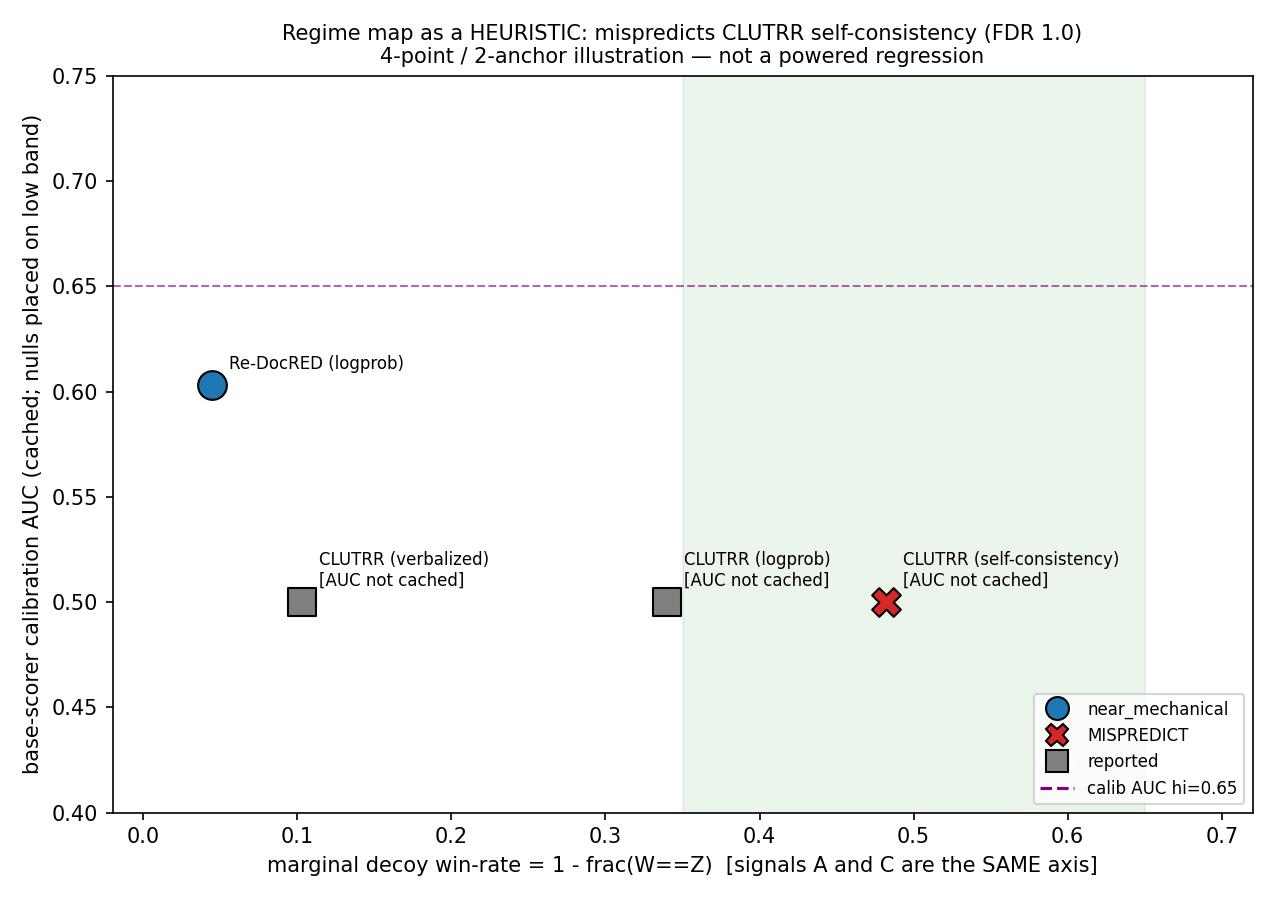

A=C IDENTITY  (frac(W==Z) == 1 - winrate, exactly up to the Z=Zt=0 tie fraction)
verdict: CONFIRMED   corr(a,c)=-0.9842804441568241   max_residual=1.826e-03  max_tie_frac=6.209e-03
------------------------------------------------------------------------------
set                            n   winrate   frac_eq    1-winr    residual
------------------------------------------------------------------------------
all                         2891   0.05880   0.94293   0.94120    1.73e-03
top_25pct                    723   0.04979   0.95021   0.95021    0.00e+00
top_50pct                   1446   0.03873   0.96127   0.96127    0.00e+00
knockoff_alpha0.2_admitted  2738   0.00621   0.99562   0.99379    1.83e-03
------------------------------------------------------------------------------
case table (machine-checked): [('a', 'Z>Zt', 2721, True), ('b', 'Z<Zt', 153, True), ('c', 'Z==Zt', 17, True)]
admitted Spearman: with ties=0.989534  without W=0 ties=1.0  jaccard=0.92478
contamination: n_con

In [13]:
def _render_figure(fp):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    Path("figures").mkdir(exist_ok=True)
    fig, ax = plt.subplots(figsize=(8.5, 6.0))
    xs = fp["x_winrate_tail"]
    ys = fp["y_calibration_auc"]
    labels = fp["labels"]
    flags = fp["flag"]
    # place null-AUC points on a low-calibration band row for visibility
    y_plot = [(y if y is not None else 0.50) for y in ys]
    colors = {"MISPREDICT": "#d62728", "near_mechanical": "#1f77b4", "reported": "#7f7f7f"}
    markers = {"MISPREDICT": "X", "near_mechanical": "o", "reported": "s"}
    for x, y, lab, fl, ycache in zip(xs, y_plot, labels, flags, ys):
        ax.scatter(x, y, s=190, c=colors.get(fl, "#333"), marker=markers.get(fl, "o"),
                   edgecolors="black", zorder=5,
                   label=None if ycache is None else None)
        tag = lab + ("\n[AUC not cached]" if ycache is None else "")
        ax.annotate(tag, (x, y), textcoords="offset points", xytext=(8, 8), fontsize=8)
    # reference lines
    band = fp["exch_band"]
    ax.axvspan(band[0], band[1], color="green", alpha=0.08, label=f"exchangeable band {band}")
    ax.axhline(fp["calib_hi"], color="purple", ls="--", lw=1, alpha=0.6, label=f"calib AUC hi={fp['calib_hi']}")
    ax.set_xlabel("marginal decoy win-rate = 1 - frac(W==Z)  [signals A and C are the SAME axis]")
    ax.set_ylabel("base-scorer calibration AUC (cached; nulls placed on low band)")
    ax.set_xlim(-0.02, 0.72)
    ax.set_ylim(0.40, 0.75)
    ax.set_title("Regime map as a HEURISTIC: mispredicts CLUTRR self-consistency (FDR 1.0)\n"
                 "4-point / 2-anchor illustration — not a powered regression", fontsize=10)
    # legend proxies
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], marker=markers[k], color="w", markerfacecolor=colors[k],
                      markeredgecolor="black", markersize=11, label=k) for k in ("near_mechanical", "MISPREDICT", "reported")]
    handles.append(Line2D([0], [0], color="purple", ls="--", label=f"calib AUC hi={fp['calib_hi']}"))
    ax.legend(handles=handles, loc="lower right", fontsize=8)
    fig.tight_layout()
    out = Path("figures") / "regime_panel.jpg"
    fig.savefig(out, dpi=150)
    plt.close(fig)
    logger.info(f"Rendered {out}")


if RENDER_FIGURE:
    _render_figure(figure_panel)
    from IPython.display import Image, display
    display(Image(filename="figures/regime_panel.jpg"))

# ----- readable summary tables -----
print("="*78)
print("A=C IDENTITY  (frac(W==Z) == 1 - winrate, exactly up to the Z=Zt=0 tie fraction)")
print(f"verdict: {identity_verdict}   corr(a,c)={corr_a_c}   "
      f"max_residual={max_resid:.3e}  max_tie_frac={max_tie:.3e}")
print("-"*78)
hdr = f"{'set':<26}{'n':>6}{'winrate':>10}{'frac_eq':>10}{'1-winr':>10}{'residual':>12}"
print(hdr); print("-"*78)
for d in per_set:
    print(f"{d['set']:<26}{d['n']:>6}{d['winrate']:>10.5f}{d['frac_eq']:>10.5f}"
          f"{d['one_minus_winrate']:>10.5f}{d['identity_residual']:>12.2e}")
print("-"*78)
print(f"case table (machine-checked): {[(c['case'], c['condition'], c['n'], c['all_hold']) for c in a_equals_c_identity['case_table_empirical']]}")
print(f"admitted Spearman: with ties={adm['admitted_spearman_with_ties']}  "
      f"without W=0 ties={adm['admitted_spearman_without_w0_ties']}  jaccard={adm['admitted_set_jaccard']}")
print(f"contamination: n_contaminated={contam['n_contaminated']}  "
      f"winrate with={contam['with_contaminated']['winrate']}  without={contam['without_contaminated']['winrate']}")
print("="*78)
print("SIGNAL DEPENDENCE: nominal=4  effective_independent_axes=2  (A==C, B refines A, only D new)")
print("="*78)
print("REGIME PANEL / MISPREDICT AUDIT")
print(f"  mispredict_count={mispredict_count}  near_mechanical_count={near_mechanical_count}  "
      f"independent_and_correct_count={independent_and_correct_count}")
for p in points:
    print(f"  - {p['label']:<28} winrate_tail={p['winrate_tail']:<7} pred={p['predicted_wedge_sign']:<9} "
          f"flag={p['flag'] if 'flag' in p else ''} mispredict={p['mispredict']}")
print("="*78)
print(f"DEMOTION VERDICT: {demotion_verdict['status']}")
print(f"LLM cost = ${llm_cost:.2f}   (zero-API, CPU-only)")